# **Εργασία 1**
Φοιτητής: Ιατρού Κωνσταντίνος 58071

Καθηγητής: Θεωδορακοπουλος Ηλίας

**Άσκηση 5**

Αναδρομική εκτίμηση Bayes: Πετάμε ένα νόμισμα Ν=10 φορές και φέρνουμε κατά σειρά
{κ,γ,κ,κ,κ,γ,κ,κ,γ,κ} (κ=κεφάλι, γ=γράμματα). Ποια είναι η πιθανότητα θ να φέρουμε κεφάλι;
Η αρχική κατανομή του θ είναι p(θ|D^0) = A*θ(1-θ)^4 (beta distribution).

In [44]:
import matplotlib.pyplot as plt
import numpy as np

Στο ερώτημα Α ζητείται να υπολογιστεί η τιμή του Α.
Κάνοντας μία προεργασία θα μπορούσαμε να πούμε ότι Α = 1/ integral(0,1){p(θ|D^0)}

In [45]:
theta = np.round(np.linspace(0, 1, 100), 2)   # Τιμές του θ με βήμα 0.01 από το 0 έως το 1
p0 = [i*(1-i)**4 for i in theta]              # Υπολογίζουμε τις τιμές της p(θ|D^0) για κάθε θ
print(1/(sum(p0)*0.01))                       # Α = 1/ολοκλήρωμα
                                              # Το άθροισμα είναι για τις διακριτές τιμές ότι το ολοκλήρωμα για τις συνεχείς

30.29155576991208


Σχόλιο: Αν δίναμε μικρότερο βήμα από 0.01 η ακρίβεια θα ήταν μεγαλύτερη και η τιμή του Α θα προσέγγιζε πρισσότερο την πραγματική που είναι 30 (Υπολογιστηκε στο report)

In [46]:
theta2 = np.round(np.linspace(0, 1, 100000), 5)
p0_2 = [i*(1-i)**4 for i in theta2]              # Υπολογίζουμε τις τιμές της p(θ|D^0) για κάθε θ
print(1/(sum(p0_2)*0.00001))

30.00028126013683


**Ερώτημα β**

Θα γίνει μία απόπειρα να υπολογιστούν οι τιμές των p(θ|D^1), p(θ|D^5) και p(θ|D^10) με χρήση της python, αλλά για την δημιουργία των τελικών γραφικών παραστάσεων θα χρησιμοποιηθούν οι συναρτήσεις όπως υπολογίστηκαν στο report.

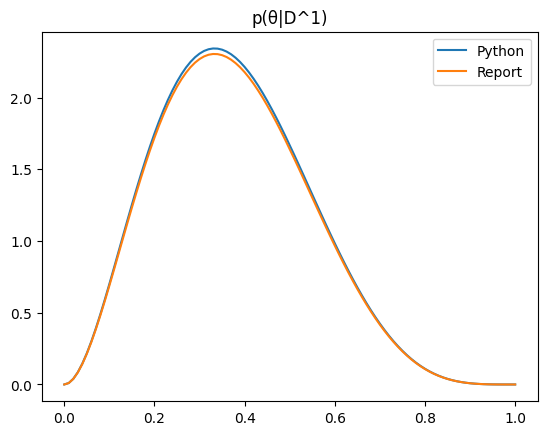

In [47]:
px_theta_head = [i for i in theta]    # p(x|θ) = θ (Εάν κεφάλι)
px_theta_tail = [1-i for i in theta]  # p(x|θ) = 1-θ (Εάν γράμματα)

p_theta_D1_num = [(px_theta_head[i]*p0[i]) for i in range(len(theta))]  # Υπολογισμός του αριθμιτή για το κλάσμα του p(θ|D^1) το οποίο είναι (θ^1)*((1-θ)^0)*p(θ|D^0)
p_theta_D1_denum = sum(p_theta_D1_num)*0.01                             # Υπολογισμός του παρονομαστή για το κλάσμα του p(θ|D^1) που είναι το ολοκλήρωμα για θ από 0 έως 1 του αριθμιτή από πάνω.
p_theta_D1 = p_theta_D1_num/p_theta_D1_denum                            # Τιμές της p(θ|D^1) υπολογισμένες στην Python

p1 = [105*(i**2)*(1-i)**4 for i in theta]     # Τιμές της p(θ|D^1) υπολογισμένες στο χέρι (Report)

plt.plot(theta, p_theta_D1)
plt.plot(theta, p1)
plt.title("p(θ|D^1)")
plt.legend(['Python', 'Report'])
plt.show()

Φαίνεται πως γίνεται αρκετά καλή προσέγγιση της λύσης και με χρήση της python. Όσο μικρότερο βέβαια το βήμα του θ, τόσο πιο κοντά στην πραγματική λύση θα είναι η προσέγγιση της python.

Στη συνέχεια για τον υπολογισμό της p(θ|D^5):

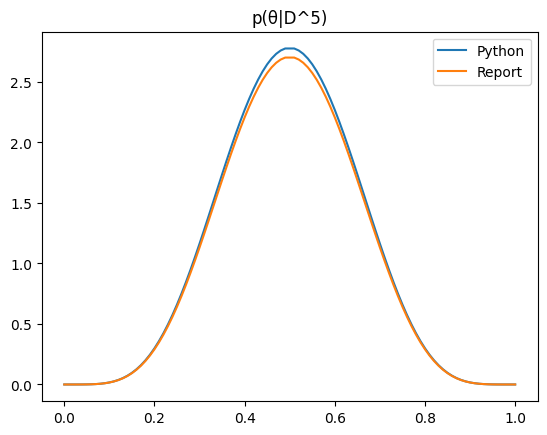

In [48]:
p_theta_D5_num = [((px_theta_head[i]**4)*px_theta_tail[i]*p0[i]) for i in range(len(theta))]  # Υπολογισμός του αριθμιτή για το κλάσμα του p(θ|D^5) το οποίο είναι (θ^4)*((1-θ)^1)*p(θ|D^0)
p_theta_D5_denum = sum(p_theta_D5_num)*0.01                             # Υπολογισμός του παρονομαστή για το κλάσμα του p(θ|D^5) που είναι το ολοκλήρωμα για θ από 0 έως 1 του αριθμιτή από πάνω.
p_theta_D5 = p_theta_D5_num/p_theta_D5_denum                            # Τιμές της p(θ|D^5) υπολογισμένες στην Python

p5 = [2772*(i**5)*(1-i)**5 for i in theta]     # Τιμές της p(θ|D^5) υπολογισμένες στο χέρι (Report)

plt.plot(theta, p_theta_D5)
plt.plot(theta, p5)
plt.title("p(θ|D^5)")
plt.legend(['Python', 'Report'])
plt.show()

Τέλος το p(θ|D^10):

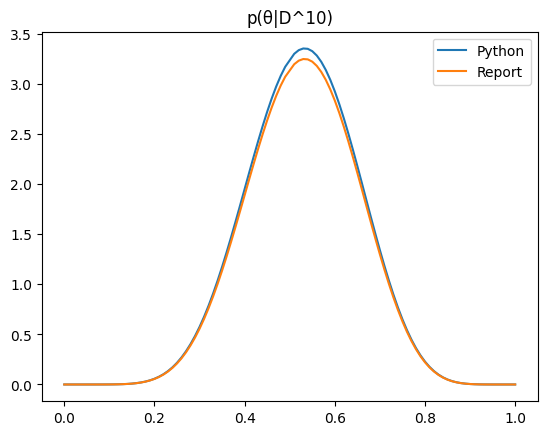

In [49]:
p_theta_D10_num = [((px_theta_head[i]**7)*(px_theta_tail[i]**3)*p0[i]) for i in range(len(theta))]  # Υπολογισμός του αριθμιτή για το κλάσμα του p(θ|D^5) το οποίο είναι (θ^4)*((1-θ)^1)*p(θ|D^0)
p_theta_D10_denum = sum(p_theta_D10_num)*0.01                             # Υπολογισμός του παρονομαστή για το κλάσμα του p(θ|D^5) που είναι το ολοκλήρωμα για θ από 0 έως 1 του αριθμιτή από πάνω.
p_theta_D10 = p_theta_D10_num/p_theta_D10_denum                            # Τιμές της p(θ|D^5) υπολογισμένες στην Python

p10 = [102960*(i**8)*(1-i)**7 for i in theta] # Τιμές της p(θ|D^10) υπολογισμένες στο χέρι (Report)

plt.plot(theta, p_theta_D10)
plt.plot(theta, p10)
plt.title("p(θ|D^10)")
plt.legend(['Python', 'Report'])
plt.show()

**Σχόλιο:** Είναι φανερό ότι όσο πιο μεγάλος ο 'βαθμός' του D σφάλμα μεταξύ της υπολογισμένης στο χέρι συνάρτησης και αυτής που υπολογίστηκε στην python είναι μεγαλύτερο. Αυτό γιατί σε κάθε πολλαπλασιασμό-δύναμη που βάζουμε υπάρχει ένα σφάλμα το οποίο αθροίζεται (για την ακρίβεια πολλαπλασιάζεται) από το p(θ|D^1) -> p(θ|D^2) -> ... -> p(θ|D^10).

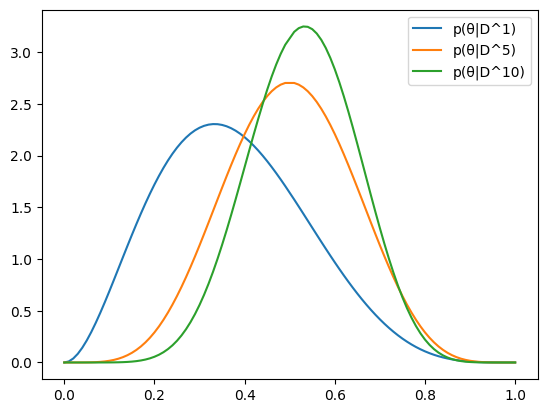

In [50]:
# Οι συναρτήσεις υπολογίστηκαν στο report και απλά εδώ θα γίνει η αναπαράσταση τους.
p1 = [105*(i**2)*(1-i)**4 for i in theta]     # Τιμές της p(θ|D^1)
p5 = [2772*(i**5)*(1-i)**5 for i in theta]    # Τιμές της p(θ|D^5)
p10 = [102960*(i**8)*(1-i)**7 for i in theta] # Τιμές της p(θ|D^10)

plt.plot(theta, p1)   # Γραφική παράσταση της p(θ|D^1)
plt.plot(theta, p5)   # Γραφική παράσταση της p(θ|D^5)
plt.plot(theta, p10)  # Γραφική παράσταση της p(θ|D^10)
plt.legend(['p(θ|D^1)', 'p(θ|D^5)', 'p(θ|D^10)']) # Λεζάντες για να γνωρίζουμε τα γραφήματα

plt.show()  # Εμφανιση της εικόνας με κοινό διάγραμμα των τριών γραφικών παραστάσεων

Με την χρήση της python είναι δυνατό να υπολογιστεί και προσεγγιστικά η τιμή του p(x=γ|D^10)

In [51]:
p_t_D10_inside_integral = [102960*(i**8)*(1-i)**8 for i in theta] # Εδώ θέλω να υπολογίσω τις τιμές της συνάρτησης που βρίσκονται μέσα στο
                                                                  # ολοκλήρωμα που παίρνουμε για να υπολογίσουμε το p(x=γ|D^10).
                                                                  # (Βρίσκεται μέσα στην αναφορά αναλυτικα)
p_t_D10 = sum(p_t_D10_inside_integral)*0.01                       # Το άθροισμα είναι το αντίστοιχο του ολοκληρώματος στις διακριτές τιμές.
                                                                  # Πολλαπλασιάζω με 0.01 γιατί αυτό είναι το βήμα του θ. (Είναι το dθ)
print(p_t_D10)

0.4548777860753679


Παρατηρούμε μία μικρή απόκλιση στα αποτελέσματα, αλλά να μεγαλώσουμε την διακριτότητα κάνοντας το βήμα του θ 0.00001, θα δούμε ότι το αποτέλεσμα πλησιάζει σε αυτό που υπολογίστηκε με το χέρι στην αναφορά.

In [52]:
p_t_D10_inside_integral = [102960*(i**8)*(1-i)**8 for i in theta2]
p_t_D10 = sum(p_t_D10_inside_integral)*0.00001
print(p_t_D10)

0.4705725248448989
